# Crop phenology from on-the-fly Sentinel-2, against the EuroCropsML time series

**Thesis.** *Geospatial Foundation Models for Transparent Agricultural Monitoring under Label-Scarce Conditions*, David Reyes, ITC, University of Twente.

**What this notebook does.** It takes one parcel of each of six main Estonian crops, pulls the 2021 Sentinel-2 archive for that parcel **on the fly** with the vendored `space_time_deepsearch` loaders, and looks at the season three ways: as imagery date by date, as a vegetation-index trajectory reduced over the polygon, and as an animation with the acquisition date burned into every frame. Each trajectory is then placed beside the series that **EuroCropsML** ships for the same parcel, which is the reference index Phase 1 relies on.

**Why it matters for Phase 1.** The chips this thesis exports are built independently of EuroCropsML, from EuroCrops polygons and a monthly Sentinel-2 composite. If the two disagree, every number compared against published EuroCropsML results inherits the difference. This notebook measures that difference on real parcels rather than assuming it away, and it establishes what a single parcel's observation record actually looks like before any compositing.

**Sources.**

| | what | how |
|---|---|---|
| imagery | Sentinel-2 L2A surface reflectance, Microsoft Planetary Computer | `space_time_deepsearch.io.get_sentinel2_imagery`, STAC search and `stackstac` |
| radar | Sentinel-1 RTC gamma0 | `space_time_deepsearch.io.get_sentinel1_rtc_imagery` and `compute_features` |
| reference series | EuroCropsML `.npz`, Sentinel-2 **L1C top of atmosphere**, spatial median over the same polygon | Zenodo record 15095445 |
| polygons | EuroCrops v11, Estonia 2021 | Zenodo record 14094196 |

**Provenance.** Every figure and number here is produced by `results/eda/eurocrops/_parcel_gallery.py`, which writes `gallery.json`, the cached series under `results/eda/eurocrops/cache/` and the figures under `results/eda/eurocrops/figures/gallery/`. The animations are written to `data/eurocrops/gallery/`, which is git-ignored. Season 2021-03-01 to 2021-11-15, scenes kept at tile cloud below 70 % and coverage at least 80 %, bands B02, B03, B04, B05, B08, B11, SCL.

## 0. Setup

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
sns.set_theme(context="notebook", style="whitegrid")


def find_repo(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "CLAUDE.md").exists() or (p / ".git").exists():
            return p
    raise RuntimeError("repository root not found")


REPO = find_repo(Path.cwd().resolve())
EDA = REPO / "results" / "eda" / "eurocrops"
FIG = EDA / "figures" / "gallery"
CACHE = EDA / "cache"
GIF = REPO / "data" / "eurocrops" / "gallery"

gallery = json.loads((EDA / "gallery.json").read_text())
series = pd.read_parquet(CACHE / "gallery_ndvi_series.parquet")
parcels = pd.read_parquet(CACHE / "gallery_parcels.parquet")
records = {p["crop"]: p for p in gallery["parcels"] if "comparison" in p}

show = lambda name, width=1000: display(Image(filename=str(FIG / name), width=width))
print(f"{len(records)} crops, {len(series):,} NDVI observations cached")
print("season:", gallery["season"], "| bands:", gallery["bands"])

6 crops, 576 NDVI observations cached
season: ['2021-03-01', '2021-11-15'] | bands: ['B02', 'B03', 'B04', 'B05', 'B08', 'B11', 'SCL']


## 1. The loaders: imagery on demand, no local archive

Nothing in this notebook reads a stored image. Both loaders live in the vendored package under `external/Space-Time-DeepSearch/`, they query a STAC catalogue at call time and build the cube with `stackstac`, so the only thing held locally is the answer.

**`io.get_sentinel2_imagery`** searches the Planetary Computer `sentinel-2-l2a` collection over an area of interest and a date range, then does the filtering that matters for a parcel: it loads the scene classification layer, computes the cloud fraction **over the area of interest itself** rather than trusting the tile-level `eo:cloud_cover`, drops scenes below a coverage threshold, mosaics overlapping tiles of the same date, and optionally composites onto a fixed period. It returns a dense `(time, band, y, x)` array in the local UTM zone.

**`io.get_sentinel1_rtc_imagery`** is the radar counterpart: no cloud logic, reductions kept in linear power, with `relative_orbit` and `orbit_state` carried through as coordinates so that the track offset can be removed afterwards. `compute_features` reduces it over a polygon and reports the medians in decibels.

**`vis.create_timelapse`** turns any cube with a time dimension into an animation, in true colour or through a colormap, with the acquisition date drawn on each frame.

**`vis.parcel_timeseries.compute_indices`** reduces a clipped cube to the per-date median of NDVI, EVI, EVI2, NDMI and NDRE, applying an SCL blacklist first, and also returns Moran's I per date, which measures how spatially organised the parcel is on that day.

Two changes were needed to use these here, both worth carrying back upstream:

1. `io/__init__.py` imported every loader eagerly, so `import space_time_deepsearch.io` required `osmnx` even when only Sentinel-2 was wanted. It now resolves each loader on first use, exactly as `vis/__init__.py` already did.
2. `compute_indices` hard-codes `BOA_ADD_OFFSET = -1000`. That constant is correct only from **processing baseline 04.00**, operational on 25 January 2022. Section 5 shows what it does to 2021 data.

In [2]:
print("the call this notebook's data came from:\n")
print(f"""get_sentinel2_imagery(
    custom_geometry = <parcel bounding box buffered by {gallery['buffer_m']} m, EPSG:4326>,
    start_date      = "{gallery['season'][0]}",
    end_date        = "{gallery['season'][1]}",
    bands           = {gallery['bands']},
    resolution      = 10,
    cloud_cover_max = {gallery['cloud_cover_max']},     # measured over the AOI, not the tile
    min_coverage    = {gallery['min_coverage']},
)""")

the call this notebook's data came from:

get_sentinel2_imagery(
    custom_geometry = <parcel bounding box buffered by 250 m, EPSG:4326>,
    start_date      = "2021-03-01",
    end_date        = "2021-11-15",
    bands           = ['B02', 'B03', 'B04', 'B05', 'B08', 'B11', 'SCL'],
    resolution      = 10,
    cloud_cover_max = 70,     # measured over the AOI, not the tile
    min_coverage    = 80,
)


## 2. The parcels

One parcel per crop, chosen so that the imagery shows the crop rather than the boundary: between 8 and 25 hectares, compactness above 0.65, and **the same HCAT code in both releases**, since notebook 03 showed the two disagree on about one Latvian parcel in six. Everything else about the parcel is whatever Estonia declared.

In [3]:
tbl = parcels.set_index("crop")[["label", "parcel_id", "hcat", "area_ha", "n_pixels",
                                 "compactness", "edge_share", "candidates"]]
display(tbl)
rows = [{"crop": c, "scenes retained": r["scenes_retained"],
         "clear over parcel": r["scenes_clear_over_parcel"],
         "median clear fraction": r["median_clear_fraction"],
         "EuroCropsML dates": r["comparison"]["dates_l1c_eurocropsml"],
         "NUTS3": r["nuts3"]}
        for c, r in records.items()]
display(pd.DataFrame(rows).set_index("crop"))

,label,parcel_id,hcat,area_ha,n_pixels,compactness,edge_share,candidates
crop,,,,,,,,
winter_common_soft_wheat,winter wheat,21121746,3301010101,10.97,1096,0.875,0.114,1009
spring_barley,spring barley,20583785,3301010402,9.19,918,0.872,0.125,666
winter_rapeseed_rape,winter rapeseed,21534249,3301060401,17.46,1746,0.865,0.091,477
potatoes,potatoes,21084265,3301030000,13.67,1367,0.828,0.105,22
pasture_meadow_grassland_grass,grassland,21652845,3302000000,13.31,1331,0.911,0.102,1132
oats,oats,20908606,3301010500,11.74,1174,0.849,0.112,299


,scenes retained,clear over parcel,median clear fraction,EuroCropsML dates,NUTS3
crop,,,,,
winter_common_soft_wheat,72,64,1.000,59,EE009
spring_barley,42,38,1.000,48,EE004
winter_rapeseed_rape,46,38,0.992,44,EE008
potatoes,39,35,1.000,36,EE009
pasture_meadow_grassland_grass,60,54,1.000,54,EE009
oats,64,60,1.000,72,EE004


## 3. Crop by crop

Each crop gets two figures. The **contact sheet** is twelve true-colour frames spread across the season, each titled with its acquisition date and the share of the parcel that was clear on that date, with the declared boundary drawn in yellow. The stretch is fixed at 0 to 0.30 reflectance for every date, so the frames can be compared with each other. The **series figure** shows the five indices computed here, then NDVI against the EuroCropsML series, then the two matched date by date.

,dates,peak_ndvi,peak_date,ndvi_above_0.5_from,until,days,sharp_drops
oats,59,0.852,2021-09-09,2021-06-06,2021-09-27,113,6
pasture_meadow_grassland_grass,48,0.868,2021-09-26,2021-06-18,2021-11-12,147,4
potatoes,30,0.847,2021-08-10,2021-07-18,2021-08-22,35,2
spring_barley,35,0.9,2021-06-11,2021-05-29,2021-10-11,135,3
winter_common_soft_wheat,56,0.898,2021-05-29,2021-05-12,2021-11-02,174,3
winter_rapeseed_rape,35,0.861,2021-06-18,2021-03-02,2021-11-12,255,4


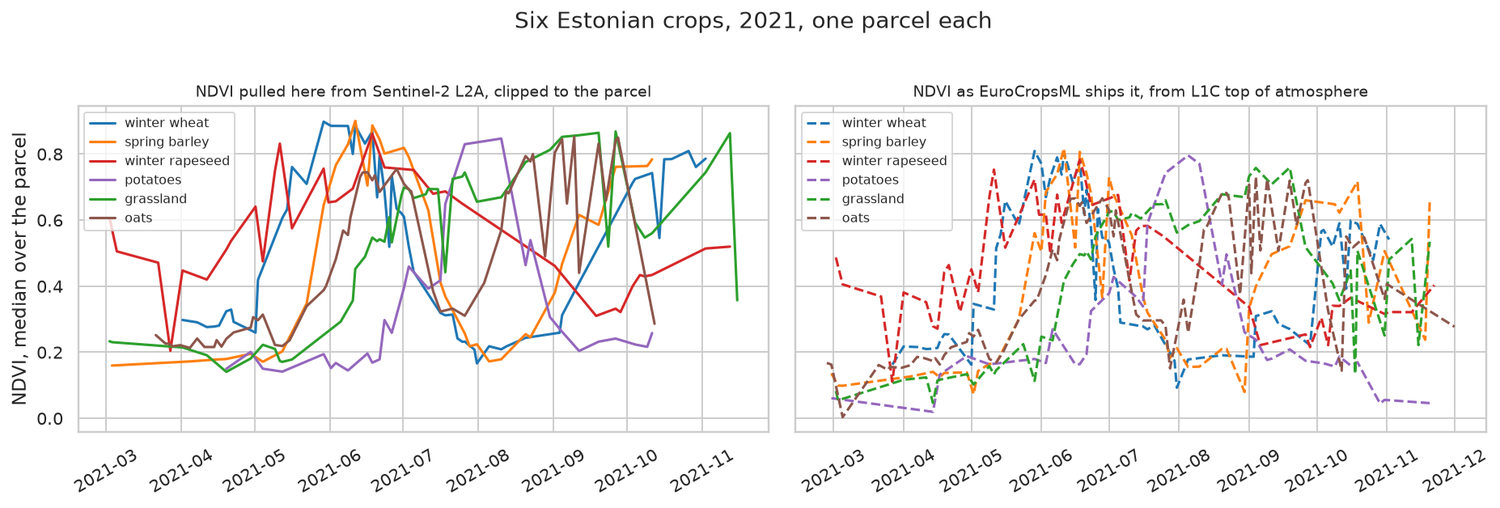

In [4]:
def phenology(df, thr=0.5, drop=0.15, window=25):
    """Green-up, peak, senescence and sharp drops, read off the NDVI trajectory."""
    d = df.sort_values("date")
    dates = pd.to_datetime(d["date"]).to_numpy()
    v = d["median"].to_numpy(dtype=float)
    ok = np.isfinite(v)
    dates, v = dates[ok], v[ok]
    above = v >= thr
    out = {"dates": len(v), "peak_ndvi": round(float(v.max()), 3),
           "peak_date": str(pd.Timestamp(dates[int(v.argmax())]).date())}
    if above.any():
        out["ndvi_above_0.5_from"] = str(pd.Timestamp(dates[int(np.argmax(above))]).date())
        out["until"] = str(pd.Timestamp(dates[len(above) - 1 - int(np.argmax(above[::-1]))]).date())
        out["days"] = (pd.Timestamp(out["until"]) - pd.Timestamp(out["ndvi_above_0.5_from"])).days
    out["sharp_drops"] = sum(
        1 for i in range(1, len(v))
        if (pd.Timestamp(dates[i]) - pd.Timestamp(dates[i - 1])).days <= window
        and (v[i - 1] - v[i]) >= drop)
    return out


ours = series[series["source"] == "s2_l2a_here"]
phen = pd.DataFrame({c: phenology(g) for c, g in ours.groupby("crop")}).T
display(phen)
show("00_overview_ndvi.png", width=1100)

The six trajectories separate exactly where agronomy says they should, and the panel on the right shows that EuroCropsML tells the same story with the same shape.

The winter crops, wheat and rapeseed, are already green when the season opens in March, because they were sown the previous autumn. The spring crops start from bare soil: spring barley crosses NDVI 0.5 on 2021-05-29 and oats on 2021-06-06, two months after the winter crops. Potatoes are later still and hold their canopy into August. Grassland is the odd one out, and section 3.6 returns to it.

### 3.1 winter wheat

Parcel 21121746, 10.97 ha, 1,096 pixels, HCAT 3301010101, NUTS3 EE009. 72 scenes survived the tile filter and 64 were at least 60 % clear over the parcel itself.

Sown the previous autumn, so the parcel is already green in early March and never passes through bare soil. The canopy closes through May, peaks at **0.898** on **2021-05-29**, then senesces: the NDVI fall through July is the grain ripening, not a loss of the crop, and the sharp step at the end is the harvest. The contact sheet shows the same thing without any index: a dark green field in June, a pale straw-coloured one in August.

Then NDVI climbs back above 0.7 from September. That is not the declared crop. It is what followed it, a catch crop or the next winter cereal, and it matters for this thesis: the parcel carries **one label for 2021 and two distinct canopies**. Any representation that averages the year, AlphaEarth's annual embedding in particular, sees the mixture rather than the wheat.

Against EuroCropsML: 51 dates match within one day, r = 0.974, mean NDVI difference +0.096.

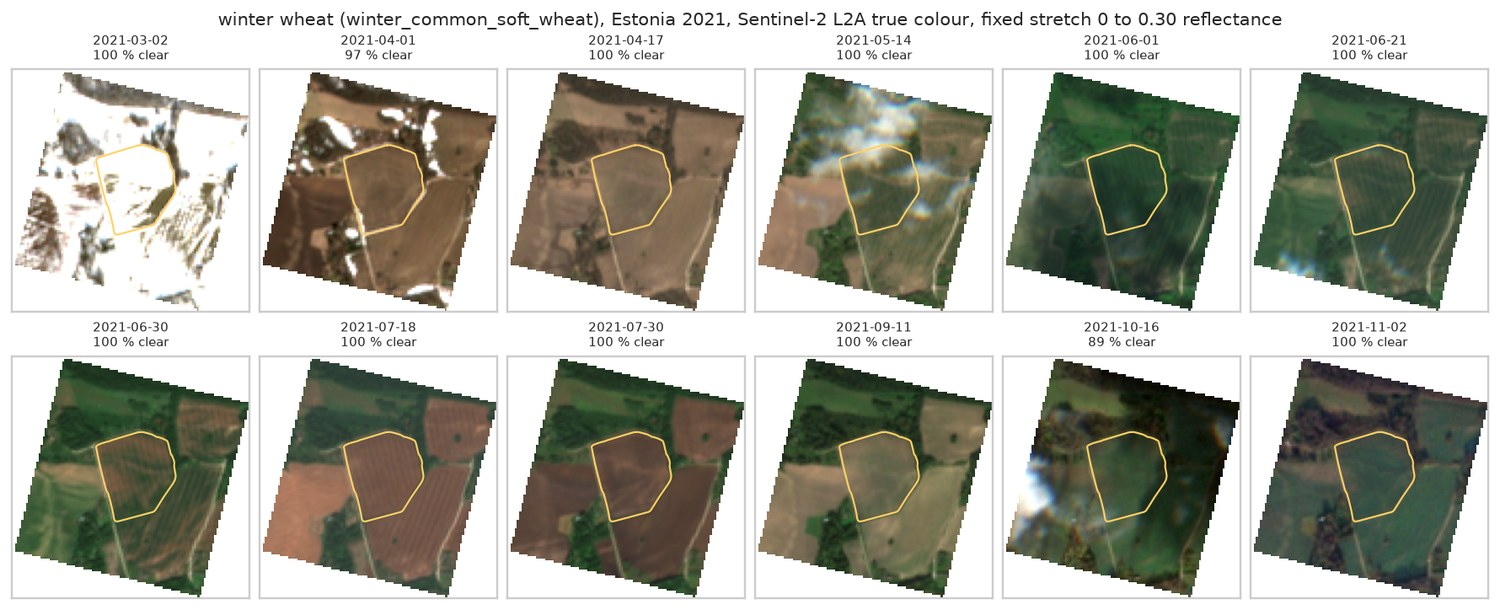

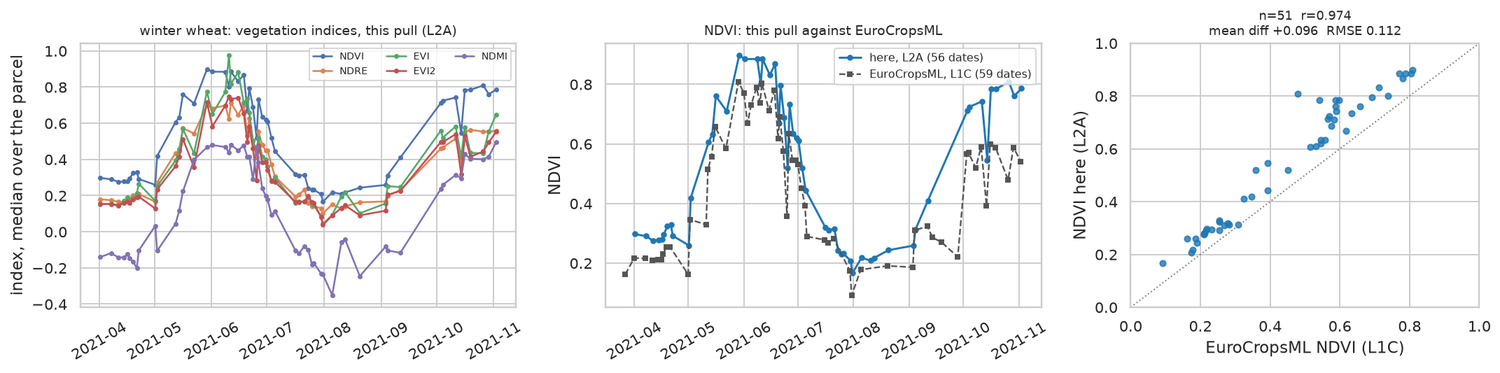

In [5]:
show("winter_common_soft_wheat_contact.jpg", width=1150)
show("winter_common_soft_wheat_series.png", width=1150)

### 3.2 winter rapeseed

Parcel 21534249, 17.46 ha, 1,746 pixels, HCAT 3301060401, NUTS3 EE008. 46 scenes survived the tile filter and 38 were at least 60 % clear over the parcel itself.

The most distinctive signature of the six. Rapeseed flowers in May, and the flowering canopy is bright yellow, which **raises reflectance in the green and red bands and therefore pushes NDVI down while the crop is at its most vigorous**. Peak NDVI here is 0.861 on 2021-06-18, and the interesting part of the curve is the dip that precedes it in the second half of May. The contact sheet settles what caused it: the **31 May** frame shows the parcel and its neighbour bright yellow, which is flowering, not cloud. A classifier reading NDVI alone sees a stressed cereal; a classifier reading the visible bands sees a field no other crop resembles, which is why rapeseed is usually among the easiest classes and why band-level attribution in Phase 2 should show the visible bands carrying the decision.

Against EuroCropsML: 34 dates match within one day, r = 0.970, mean NDVI difference +0.099.

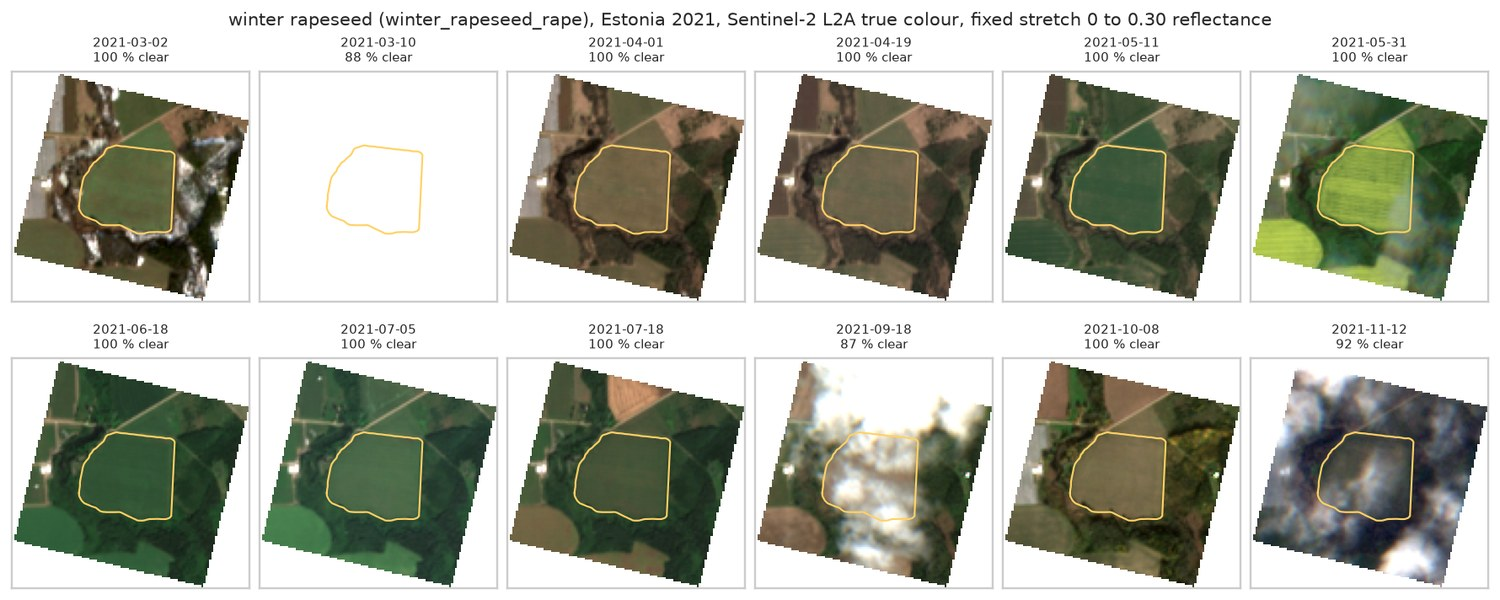

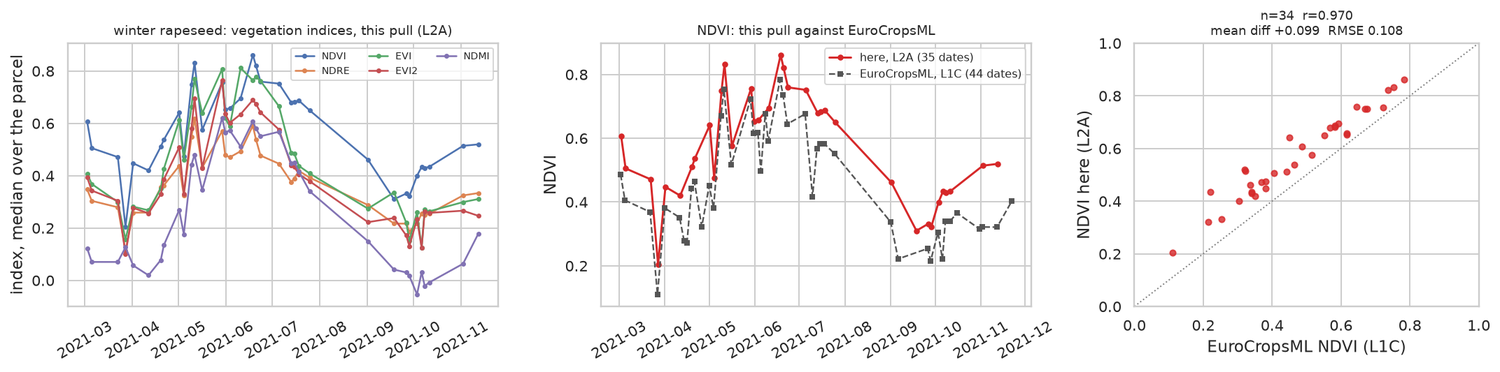

In [6]:
show("winter_rapeseed_rape_contact.jpg", width=1150)
show("winter_rapeseed_rape_series.png", width=1150)

### 3.3 spring barley

Parcel 20583785, 9.19 ha, 918 pixels, HCAT 3301010402, NUTS3 EE004. 42 scenes survived the tile filter and 38 were at least 60 % clear over the parcel itself.

Bare soil until sowing, then a fast rise: NDVI crosses 0.5 on 2021-05-29 and peaks at 0.9 on 2021-06-11. The season is compressed, 135 days above 0.5, and the drop at the end is abrupt because barley is harvested green-ripe over a few days. This is the shape that a fixed monthly composite is most at risk of blurring.

Against EuroCropsML: 35 dates match within one day, r = 0.995, mean NDVI difference +0.069.

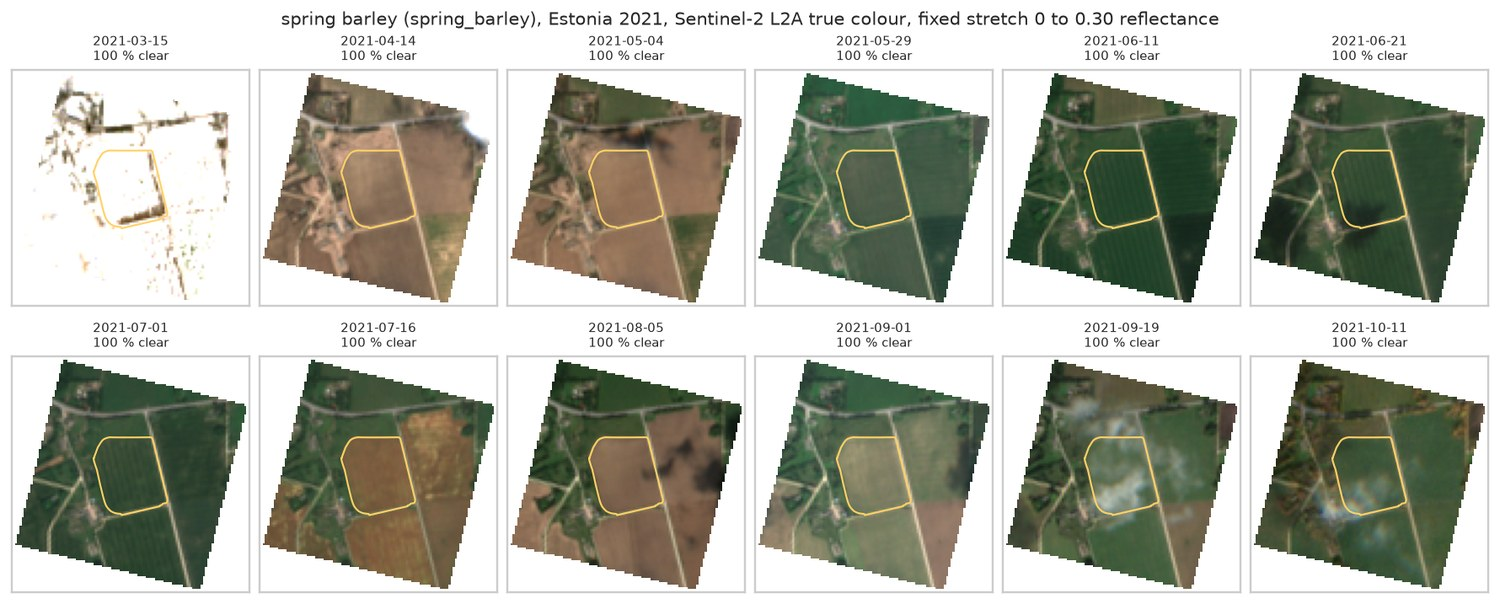

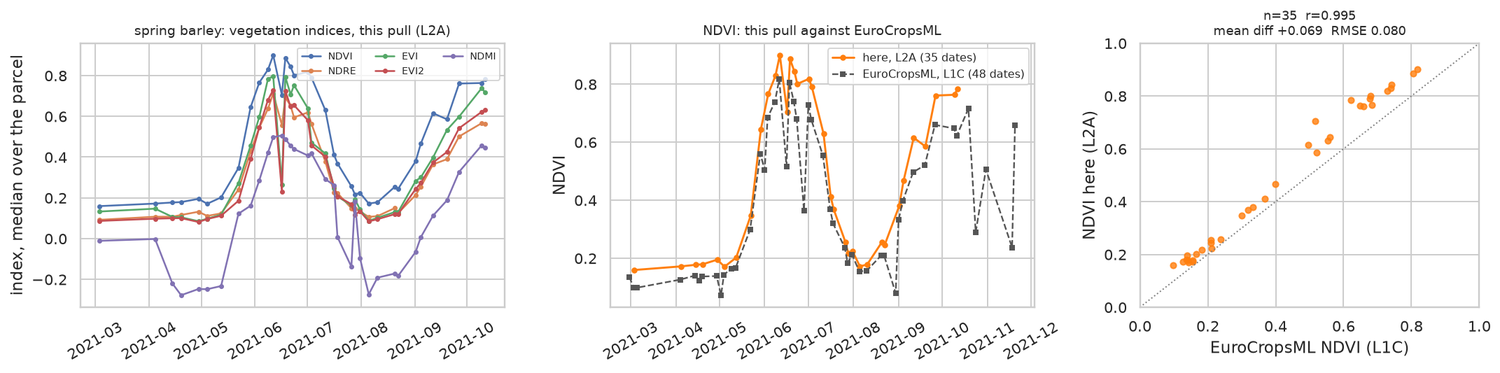

In [7]:
show("spring_barley_contact.jpg", width=1150)
show("spring_barley_series.png", width=1150)

### 3.4 oats

Parcel 20908606, 11.74 ha, 1,174 pixels, HCAT 3301010500, NUTS3 EE004. 64 scenes survived the tile filter and 60 were at least 60 % clear over the parcel itself.

The same spring-crop shape as barley, displaced later: green-up on 2021-06-06, peak 0.852 on 2021-09-09. The separation between oats and barley lives in the timing rather than in the spectra, which is the strongest argument in this notebook for keeping temporal resolution: with a single annual composite the two are nearly the same field.

Against EuroCropsML: 57 dates match within one day, r = 0.994, mean NDVI difference +0.076.

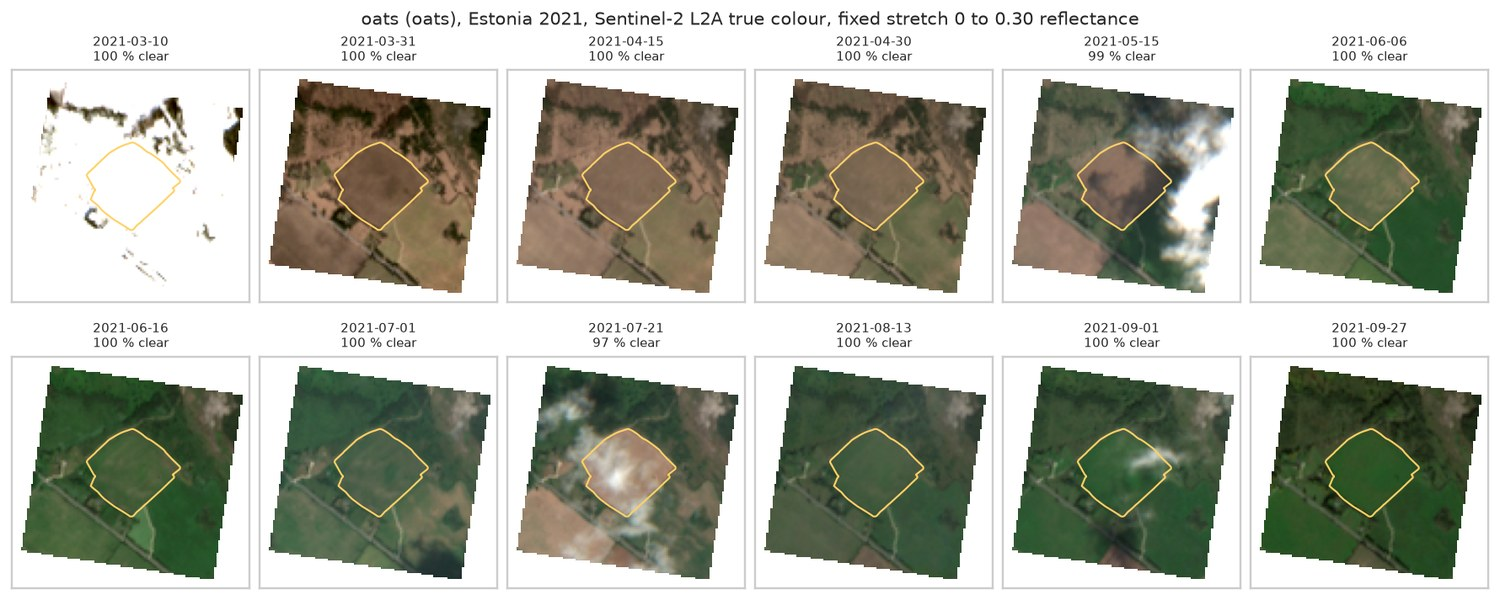

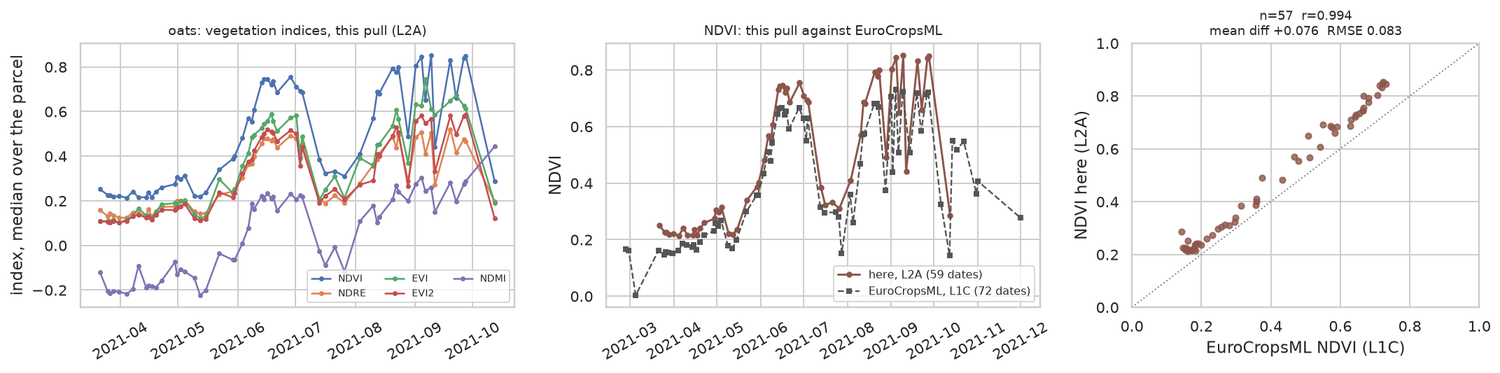

In [8]:
show("oats_contact.jpg", width=1150)
show("oats_series.png", width=1150)

### 3.5 potatoes

Parcel 21084265, 13.67 ha, 1,367 pixels, HCAT 3301030000, NUTS3 EE009. 39 scenes survived the tile filter and 35 were at least 60 % clear over the parcel itself.

The latest emergence of the six and the longest green plateau, 35 days above NDVI 0.5, peaking at 0.847 on 2021-08-10. The decline is gradual, as haulm senescence and desiccation precede lifting. Row structure is visible in the contact sheet even at 10 m, which is one reason potato parcels tend to show high within-parcel variance.

Against EuroCropsML: 23 dates match within one day, r = 0.991, mean NDVI difference +0.037.

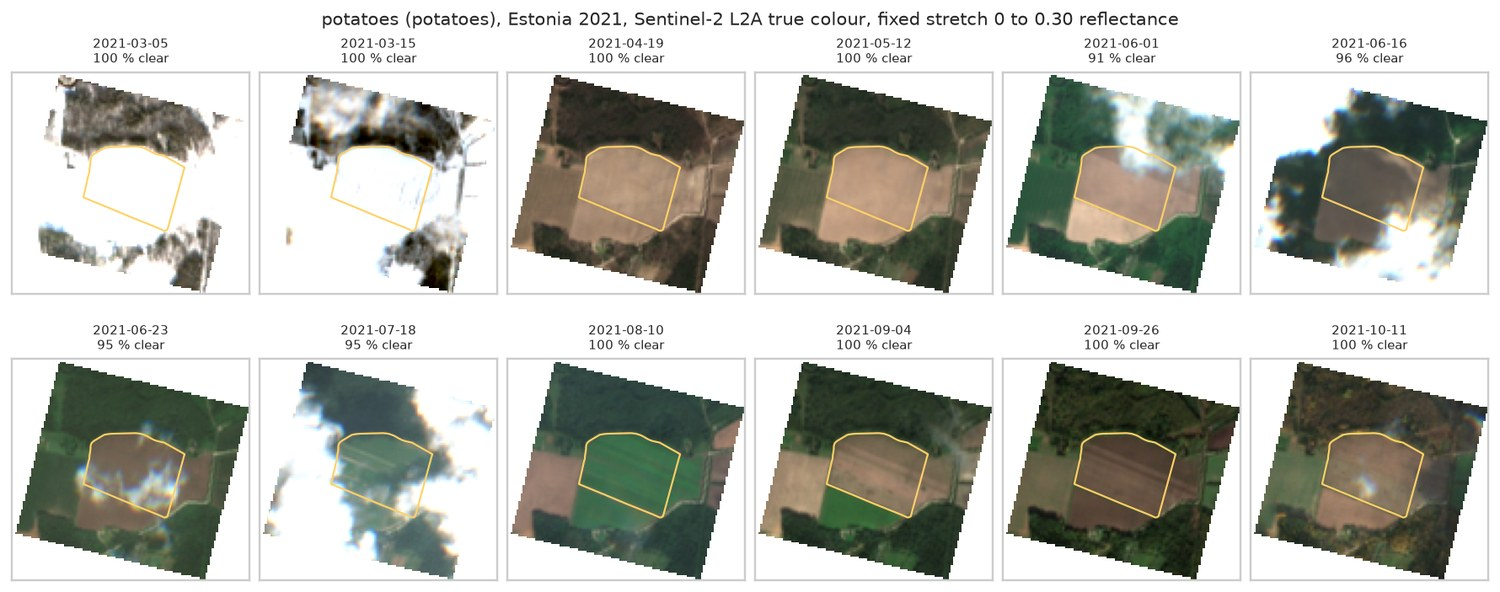

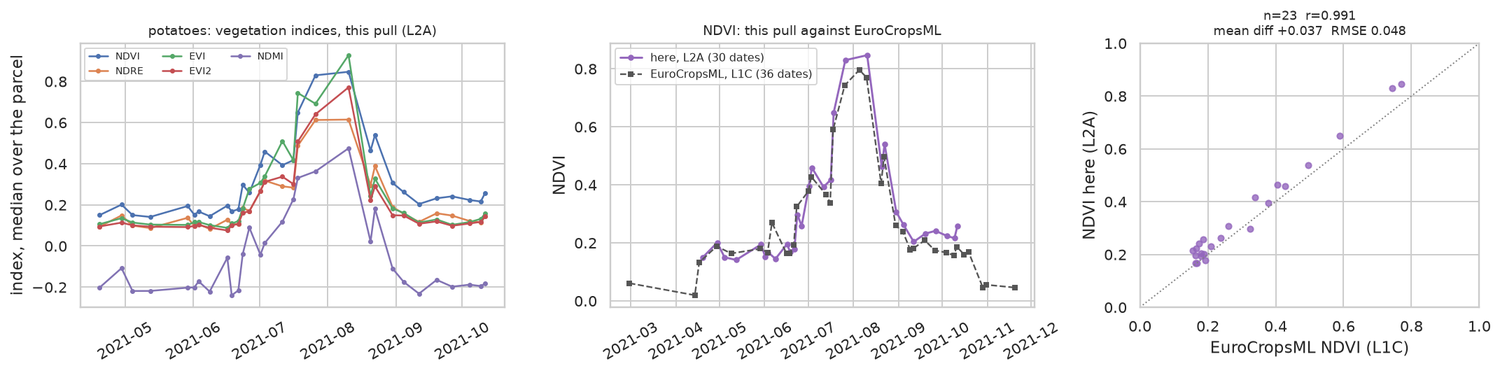

In [9]:
show("potatoes_contact.jpg", width=1150)
show("potatoes_series.png", width=1150)

### 3.6 grassland

Parcel 21652845, 13.31 ha, 1,331 pixels, HCAT 3302000000, NUTS3 EE009. 60 scenes survived the tile filter and 54 were at least 60 % clear over the parcel itself.

Green from the first clear date to the last, with no single peak. What defines grassland is not a curve but a set of interruptions: 4 sharp NDVI drops, each a cut or a grazing event, followed by regrowth. The parcel median alone cannot distinguish a whole field mown from a partial cut, which is precisely the problem the vendored `compute_indices` returns Moran's I for, and which is the subject of the separate Terramind internship.

Against EuroCropsML: 43 dates match within one day, r = 0.938, mean NDVI difference +0.095.

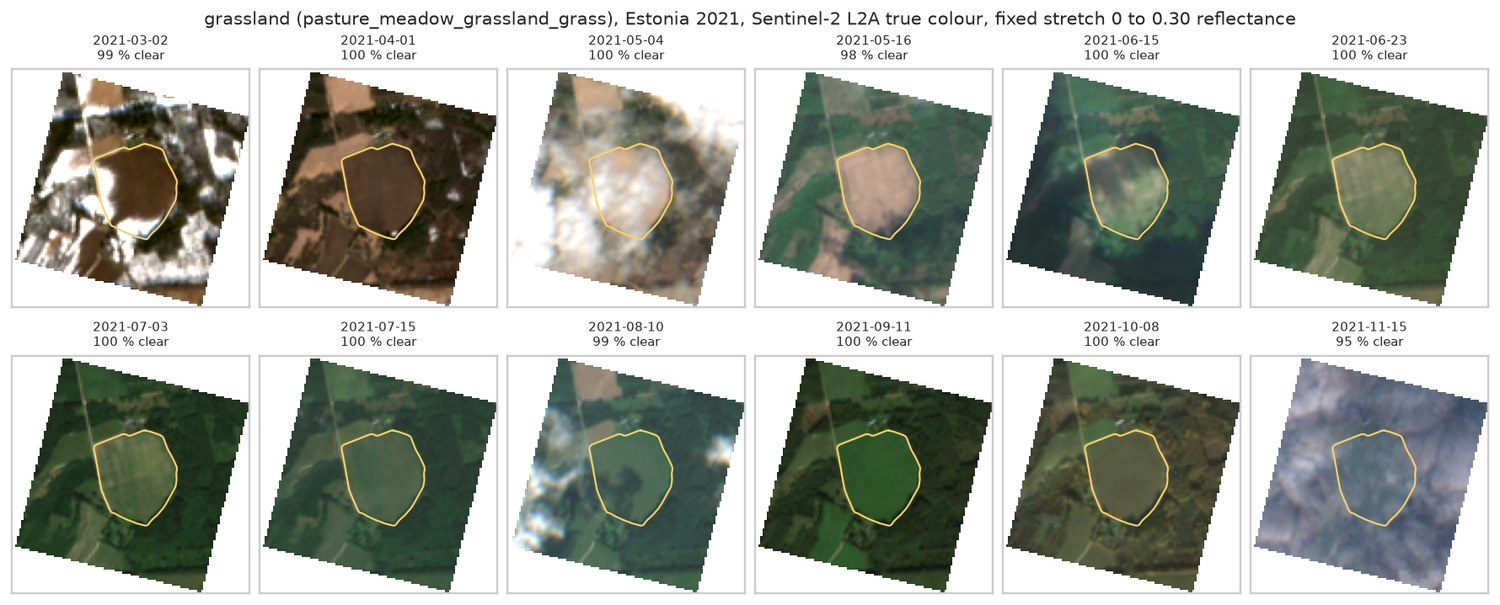

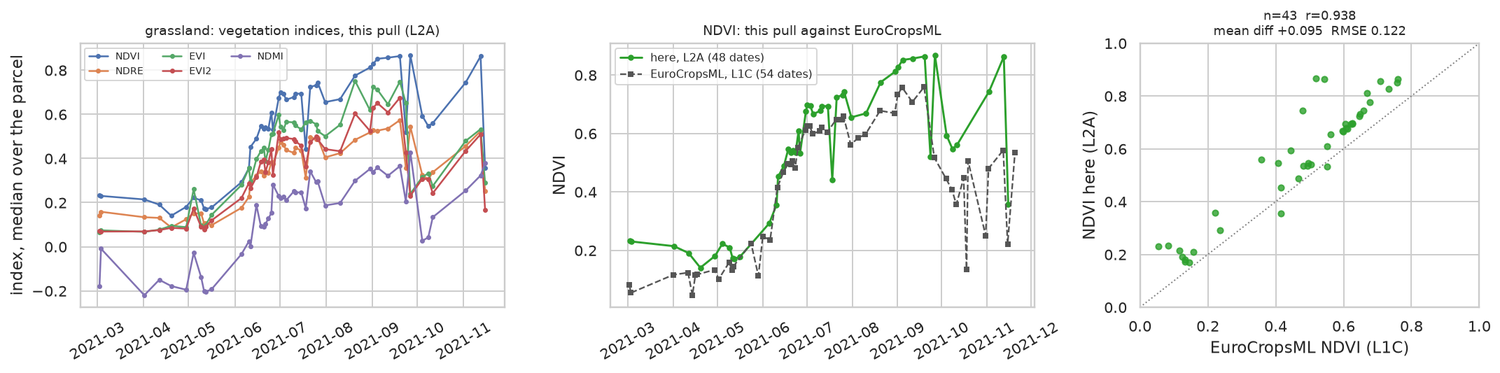

In [10]:
show("pasture_meadow_grassland_grass_contact.jpg", width=1150)
show("pasture_meadow_grassland_grass_series.png", width=1150)

## 4. The animations

`create_timelapse` writes one frame per acquisition with the date drawn on it, which is the quickest way to see what a parcel actually did and, just as usefully, what the cloud screening let through. The files are written to `data/eurocrops/gallery/` and are git-ignored, since each is a few megabytes.

The showcase parcel gets two: true colour, and NDVI through a brown-to-green ramp on a fixed scale so that the colour means the same thing in every frame.

  2.4 MB  data/eurocrops/gallery/oats_rgb.gif
  2.1 MB  data/eurocrops/gallery/pasture_meadow_grassland_grass_rgb.gif
  1.2 MB  data/eurocrops/gallery/potatoes_rgb.gif
  1.4 MB  data/eurocrops/gallery/spring_barley_rgb.gif
  2.4 MB  data/eurocrops/gallery/winter_common_soft_wheat_ndvi.gif
  0.9 MB  data/eurocrops/gallery/winter_common_soft_wheat_ndvi_small.gif
  2.3 MB  data/eurocrops/gallery/winter_common_soft_wheat_rgb.gif
  1.4 MB  data/eurocrops/gallery/winter_rapeseed_rape_rgb.gif
winter wheat, NDVI, one frame per clear acquisition, fixed colour scale:


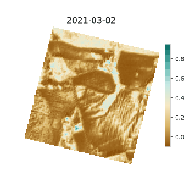

In [11]:
gifs = sorted(GIF.glob("*.gif"))
for g in gifs:
    print(f"{g.stat().st_size / 1e6:5.1f} MB  {g.relative_to(REPO)}")

# The embedded copy is the downscaled one, so the notebook does not carry two megabytes
# of base64 per animation; the full-resolution files are the ones listed above.
small = GIF / "winter_common_soft_wheat_ndvi_small.gif"
if small.exists():
    print("winter wheat, NDVI, one frame per clear acquisition, fixed colour scale:")
    display(Image(filename=str(small)))
else:
    print("run results/eda/eurocrops/_parcel_gallery.py to regenerate the animations")

## 5. Against EuroCropsML, and the offset that nearly hid it

This is the part that changes a Phase 1 decision.

In [12]:
rows = []
for crop, r in records.items():
    c = r["comparison"]
    rows.append({"crop": r["label"],
                 "dates before screening": r["dates_before_screening"],
                 "after screening": r["dates_after_screening"],
                 "EuroCropsML dates": c["dates_l1c_eurocropsml"],
                 "matched": c["matched_dates"], "r": c["pearson_r"],
                 "mean diff": c["mean_difference"], "RMSE": c["rmse"],
                 "roughness here": c["roughness_here"],
                 "roughness EuroCropsML": c["roughness_eurocropsml"]})
display(pd.DataFrame(rows).set_index("crop"))
print(json.dumps(gallery["comparison_summary"], indent=1))

,dates before screening,after screening,EuroCropsML dates,matched,r,mean diff,RMSE,roughness here,roughness EuroCropsML
crop,,,,,,,,,
winter wheat,66,56,59,51,0.9741,0.0964,0.1119,0.0367,0.0601
spring barley,38,35,48,35,0.9946,0.0690,0.0799,0.0428,0.0658
winter rapeseed,43,35,44,34,0.9702,0.0989,0.1076,0.0668,0.0820
potatoes,34,30,36,23,0.9907,0.0367,0.0477,0.0446,0.0346
grassland,56,48,54,43,0.9378,0.0951,0.1223,0.0365,0.0498
oats,63,59,72,57,0.9939,0.0759,0.0825,0.0255,0.0451


{
 "median_pearson_r": 0.9824,
 "median_mean_difference": 0.0855,
 "median_rmse": 0.095,
 "dates_here_vs_eurocropsml": {
  "winter_common_soft_wheat": [
   56,
   59
  ],
  "spring_barley": [
   35,
   48
  ],
  "winter_rapeseed_rape": [
   35,
   44
  ],
  "potatoes": [
   30,
   36
  ],
  "pasture_meadow_grassland_grass": [
   48,
   54
  ],
  "oats": [
   59,
   72
  ]
 }
}


### 5.1 Both sides need screening before they can be compared

Neither series arrives clean. `compute_indices` blacklists only nodata, saturated and snow by default, because the pipeline it came from masks clouds in the loader instead; called as it stands, with `mask_clouds=False`, it happily takes the median of a cloud. The first version of this notebook produced trajectories that fell to zero and recovered every few dates, which is not phenology.

The series here are therefore reduced with the scene classification classes 0, 1, 3, 8, 9, 10, 11 excluded per pixel, and a date is kept only when at least 60 % of the parcel survives that screening. Between 3 and 10 dates per parcel were dropped this way.

**Scene classification is not infallible, and the contact sheets prove it.** The rapeseed frame for **10 March** is a white sheet of cloud yet is scored 88 % clear, and the November frames are hazy at 92 %. SCL assigned those pixels to surface classes rather than to cloud, so neither the per-pixel blacklist nor the per-date threshold caught them. A screening rule of this kind removes the obvious failures, not the subtle ones. Two consequences: the residual is part of why the raw-feature baseline should be built on composites rather than on single dates, and a stricter blacklist, adding the dark-area and unclassified codes, is worth testing before the phenometrics of Phase 1 are computed.

### 5.2 The two series agree in shape

Across the six parcels the median correlation between the NDVI computed here and the NDVI EuroCropsML ships is **r = 0.982**, with a median RMSE of 0.095. The trajectories are the same trajectories: the same green-up, the same peak, the same harvest step.

They do not agree on noise. Measured as the median absolute change between consecutive dates, the screened series here is smoother than the EuroCropsML series for five of the six parcels (0.043 against 0.060 in the median). EuroCropsML ships one row per acquisition with its own cloud handling, and what is left over shows up as day-to-day jumps that no crop makes. **Any phenometric read off the EuroCropsML series without further smoothing, a peak date or a length of season in particular, will be measuring some of that noise**, which is a direct constraint on the TIMESAT baseline of Phase 1.

### 5.3 But they sit at different levels, and that is expected

The mean difference is **+0.086 NDVI**, positive for every crop. EuroCropsML is built from **L1C top-of-atmosphere** reflectance and this pull is **L2A surface reflectance**. Atmospheric scattering adds more path radiance to the red band than to the near infrared, so the uncorrected L1C ratio is compressed and its NDVI sits low. Correcting for the atmosphere separates the two bands again and NDVI rises.

Three consequences for Phase 1:

1. **The raw-feature baseline must state its processing level.** TIMESAT phenometrics computed on L1C and on L2A are not the same features, and an amplitude threshold tuned on one does not transfer to the other.
2. **The chips must not mix levels.** Whatever Phase 1 exports, one level is used throughout, and it is recorded in the chip manifest.
3. **Comparability with published EuroCropsML numbers costs L1C.** Track B reproduces the official splits; if it also wants to reproduce the published accuracies it should feed the model the same L1C series, and the difference against an L2A run becomes a small experiment of its own rather than an unexamined discrepancy.

### 5.4 The offset bug, which is worth knowing about

The first run of this comparison returned r = 0.50 and a mean difference of **+0.45 NDVI**, which is far too large to be an atmospheric effect. The cause was `BOA_ADD_OFFSET = -1000` in the vendored `compute_indices`.

Since processing baseline 04.00, operational on 25 January 2022, Sentinel-2 L2A stores reflectance as `(DN - 1000) / 10000`. Before that baseline it is `DN / 10000`. The vendored code was written for Austrian 2024 and 2025 data, where the offset is right. Applied to 2021, where Planetary Computer serves baselines 02.12, 03.00, 04.00, 2.12, 3.00, 4.00, it subtracts 0.1 reflectance from bands that never carried the offset. Both the red and the near-infrared band fall by 0.1, the denominator of NDVI falls by 0.2, and NDVI is inflated by roughly 0.45 on a green field.

`_parcel_gallery.py` now harmonises every date onto the `DN / 10000` convention before computing any index, reading the baseline from the cube coordinate where `stackstac` preserved it and from the STAC item properties where mosaicking dropped it, then calls `compute_indices` with `offset=0`. After the fix the same potato parcel gives r = 0.991 and a mean difference of +0.037.

The general lesson is worth carrying into the chip export: **a reflectance offset is a property of the scene, not of the collection**, and any pipeline that spans January 2022 must read the baseline per scene. Estonia and Latvia 2021 sit entirely before the change; the moment the thesis pulls a 2022 or later season, this becomes a live correctness issue.

## 6. Sentinel-1, for the same parcel

The radar loader needs no cloud logic, so it delivers a regular observation record where the optical one is ragged: **149 acquisitions** over the same season for the showcase parcel, against 64 clear optical dates. VV ranges from -15.0 to -6.07 dB and VH from -21.85 to -13.48 dB.

Backscatter is not a greenness proxy and should not be read as one: it responds to canopy structure and to water in the soil and the plant, so it keeps carrying information after the optical canopy saturates, and it reacts to a harvest immediately. In the figure VH rises with the developing canopy through May, falls at the harvest, and rises again with the autumn regrowth that NDVI also sees. The overlay is the argument for treating Sentinel-1 as a candidate modality rather than a curiosity, and TerraMind in particular is trained to take both.

Two things the loader forces one to get right, both of which cost an iteration here:

1. **`min_coverage` is measured over the bounding box of the area of interest.** A parcel polygon fills only part of its own bounding box, so the 0.8 that is sensible for a rectangular area of interest rejected all 149 dates. With a polygon it belongs at zero, and the polygon clip does the work instead.
2. **Four tracks see this parcel**, 80, 87, 153, 160, both ascending and descending, each with its own viewing geometry and therefore its own constant offset. Plotted as acquired, the series is a sawtooth that says more about the orbit than about the wheat. `normalize_orbit` removes the per-track offset and produces the lines drawn over the points.

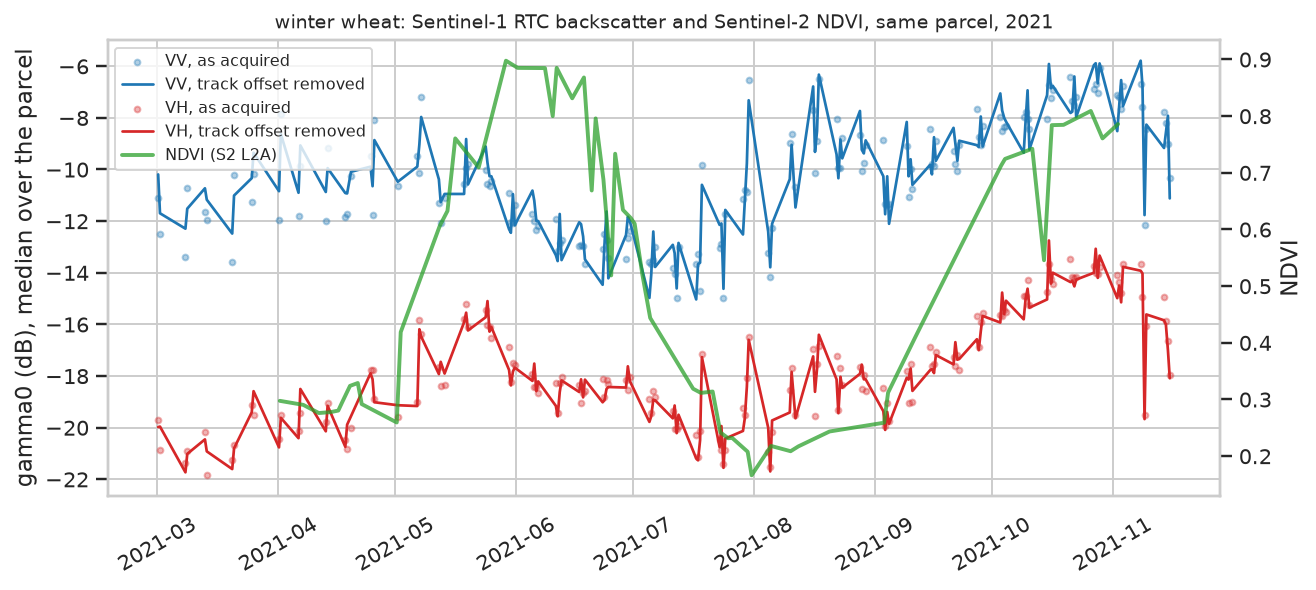

149 acquisitions, orbits [80, 87, 153, 160]


,date,relative_orbit,orbit_state,vv_median_db,vh_median_db,n_pixels
0,2021-03-01 04:42:28.124257,153,descending,-11.108008,-19.705448,1174
1,2021-03-01 15:57:02.897363,160,ascending,-12.505956,-20.888804,1174
2,2021-03-08 04:34:13.739878,80,descending,-13.409726,-21.390975,1174
3,2021-03-08 15:48:37.337623,87,ascending,-10.738825,-20.903558,1174
4,2021-03-13 04:42:28.202542,153,descending,-11.644983,-20.183010,1174
5,2021-03-13 15:57:02.986126,160,ascending,-11.979880,-21.849231,1174
6,2021-03-20 04:34:13.783012,80,descending,-13.599519,-21.265541,1174
7,2021-03-20 15:48:37.408729,87,ascending,-10.230247,-20.688909,1174


In [13]:
show("winter_common_soft_wheat_sentinel1.png", width=1000)
s1_feat = pd.read_parquet(CACHE / "gallery_sentinel1.parquet")
print(f"{len(s1_feat)} acquisitions, orbits {sorted(set(s1_feat['relative_orbit']))}")
display(s1_feat.head(8)[["date", "relative_orbit", "orbit_state", "vv_median_db", "vh_median_db", "n_pixels"]])

## 7. What this changes for Phase 1

1. **The observation record is dense, and the monthly grid throws most of it away.** These parcels retained between 30 and 59 usable L2A dates across the season, and EuroCropsML carries between 36 and 72. The planned export composites this onto **T = 12**. For grassland, whose signature is 4 sharp cuts and regrowths, a monthly median will remove exactly the events that define the class. T = 12 should be defended explicitly, or revisited.

2. **Spring cereals are separated by timing, not by spectrum.** Barley greens up on 2021-05-29 and oats on 2021-06-06. Any compositing that blurs a two-week difference collapses that separation, and no encoder recovers it afterwards.

3. **Rapeseed is a warning about NDVI-only reasoning.** Its flowering depresses NDVI at the moment the crop is most vigorous. Phase 2 attribution should show the visible bands, not the near infrared, carrying the rapeseed decision; if it does not, that is a faithfulness problem worth reporting.

4. **Processing level is a declared experimental factor.** L2A sits about +0.086 NDVI above the L1C series EuroCropsML ships. Record the level in every chip manifest and every result file.

5. **One label does not describe the whole year.** The wheat parcel is green again from September under a crop that is not the declared one. A season window has to be declared and defended, and AlphaEarth's annual embedding, which has no window at all, is being asked to represent two canopies with one vector. This is the caveat `CLAUDE.md` already states, now visible on a real parcel.

6. **The loaders are fit for the chip export.** Cloud screening measured over the area of interest rather than the tile is the right behaviour for parcel work, the returned cube is already in local UTM at 10 m, and a full season over one parcel costs seconds. The two upstream fixes made here, the lazy `io` package and the baseline-aware offset, should go back to `davidrers/Space-Time-DeepSearch`.